In [1]:
#%% 1] Importing Necessary Libraries 

import pandas as pd
import numpy as np
import os
import scipy as sp
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

### Importing Classifier models
import lightgbm as lgb
from xgboost import XGBClassifier 

#### Miscellaneous functions needed
from sklearn.decomposition import PCA
from sklearn import preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_curve
from sklearn.metrics import auc
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
import gc




Bad key "text.kerning_factor" on line 4 in
/opt/anaconda3/envs/bigdatalab_cpu_202101/lib/python3.7/site-packages/matplotlib/mpl-data/stylelib/_classic_test_patch.mplstyle.
You probably need to get an updated matplotlibrc file from
https://github.com/matplotlib/matplotlib/blob/v3.1.2/matplotlibrc.template
or from the matplotlib source distribution


In [2]:
#%% 2] Data Loading

path = '../data/'
list_files=['AOI_training.csv.zip','SPI_training_0.csv.zip','SPI_training_1.csv.zip',
'SPI_training_2.csv.zip','SPI_training_3.csv.zip']

data = []
Labels = []
for i in list_files:
    r = pd.read_csv(path+i)
    data.append(r)
    print(i)

Data = pd.concat(data[1:5])

AOI_training.csv.zip
SPI_training_0.csv.zip
SPI_training_1.csv.zip


/opt/anaconda3/envs/bigdatalab_cpu_202101/lib/python3.7/site-packages/IPython/core/interactiveshell.py:3427: DtypeWarning: Columns (17) have mixed types.Specify dtype option on import or set low_memory=False.
  exec(code_obj, self.user_global_ns, self.user_ns)


SPI_training_2.csv.zip
SPI_training_3.csv.zip


In [3]:
#%% 3] Data Preprocessing and Feature Extraction

def preprocessing_1(SPI):
    
    SPI_Data = SPI
    SPI_Data = SPI_Data.dropna()
    SPI_Data.FigureID = SPI_Data.FigureID.astype(int)
    SPI_Data['Shape(um)'] = SPI_Data['Shape(um)'].astype(float)
    SPI_Data.drop(['Date', 'Time','Result','PadID','PadType','PinNumber'],axis = 1)
    # Adding Features
    
    SPI_Data['Hypotenuse'] = ((SPI_Data['SizeX']).pow(2) + (SPI_Data['SizeY']).pow(2)).pow(0.5)
    SPI_Data['Rectangular_Area'] = (SPI_Data['SizeX'])*(SPI_Data['SizeY'])
    SPI_Data['Total_Height'] = pd.DataFrame(pd.to_numeric(SPI_Data['Height(um)']) + pd.to_numeric(SPI_Data['Shape(um)']))
    SPI_Data['Circular_Area'] = np.pi*((SPI_Data['Hypotenuse']).pow(2))
    SPI_Data['Offset_Area'] = np.pi*((SPI_Data['SizeX']).pow(2) + (SPI_Data['SizeY']).pow(2))
    SPI_Data['Polar_Coordinate'] = ((SPI_Data['PosX(mm)']).pow(2) + (SPI_Data['PosY(mm)']).pow(2)).pow(0.5)
    S = SPI_Data[['PanelID','FigureID','ComponentID','Volume(%)','Height(um)','Area(%)','OffsetX(%)','OffsetY(%)','SizeX','SizeY','Volume(um3)','Area(um2)','Shape(um)','PosX(mm)','PosY(mm)','Hypotenuse','Rectangular_Area','Total_Height','Circular_Area','Offset_Area','Polar_Coordinate']]
    
    num_columns = S.select_dtypes(include='float').columns
    aggs = {}
    for col in num_columns:
        aggs[col] = ['mean','std','var','count','min','max','median']
    SPI_agg = S.groupby(['PanelID','FigureID','ComponentID']).agg(aggs)
    SPI_agg.columns = SPI_agg.columns.map('_'.join)
    SPI_agg = SPI_agg.reset_index()

    return SPI_agg

Features = (preprocessing_1(Data)).dropna()
F = pd.DataFrame(Data.PanelID.map(str) + Data.FigureID.map(str) + Data.ComponentID)

/home/phme/jtaco/.local/lib/python3.7/site-packages/pandas/core/generic.py:5516: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self[name] = value
/opt/anaconda3/envs/bigdatalab_cpu_202101/lib/python3.7/site-packages/ipykernel_launcher.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  
/opt/anaconda3/envs/bigdatalab_cpu_202101/lib/python3.7/site-packages/ipykernel_launcher.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_index

In [4]:
#%% 4] Labelling the Data

AOI_Data = data[0]
Unique_ID_AOI = pd.DataFrame(AOI_Data[["PanelID","FigureID","ComponentID"]].values)
Unique_ID_SPI = pd.DataFrame(Features[["PanelID","FigureID","ComponentID"]].values)
Unique_ID_SPI = pd.DataFrame(Unique_ID_SPI)
Unique_ID_AOI = pd.DataFrame(Unique_ID_AOI)
c = ['col1','col2','col3']
Unique_ID_SPI.columns = c
Unique_ID_AOI.columns = c
a = Unique_ID_AOI.merge(Unique_ID_SPI, on=['col1','col2','col3'])

Labels = pd.DataFrame()
Labels = pd.DataFrame(Unique_ID_SPI[['col1','col2','col3']].isin(Unique_ID_AOI[['col1','col2','col3']]).astype(int))
L_all = Unique_ID_SPI.merge(Unique_ID_AOI.drop_duplicates(), on=['col1','col2','col3'],how='left', indicator=True)

Labels = pd.DataFrame((L_all['_merge'] == 'both').astype(int))
All = Features
All['Labels'] = Labels

In [5]:
#%% 5] Spliting Data into Training and Testing Data Sets
X_train, X_test, y_train, y_test = train_test_split(Features.drop(["PanelID","FigureID","ComponentID","Labels"],axis = 1), Labels, test_size = 0.3, random_state = 1, stratify = Labels)

#%% 6] Training Classification Models

# A] Light-GBM Classifier

clf = lgb.LGBMClassifier(boosting_type='gbdt',n_estimators=100,max_depth = -1)
clf.fit(X_train,y_train)

Y_lgbm_train = clf.predict(X_train)
Y_lgbm_test = clf.predict(X_test)

F1_train = f1_score(np.array(y_train), Y_lgbm_train)
F1_test = f1_score(np.array(y_test), Y_lgbm_test)
print('F1 Training:',F1_train)
print('F1 Validation:',F1_test)

filename = 'LIGBM.pkl'
#pickle.dump(clf, open(filename, 'wb'))

/home/phme/jtaco/.local/lib/python3.7/site-packages/sklearn/preprocessing/_label.py:98: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/home/phme/jtaco/.local/lib/python3.7/site-packages/sklearn/preprocessing/_label.py:133: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


F1 Training: 0.4259547144305509
F1 Validation: 0.4234645669291339


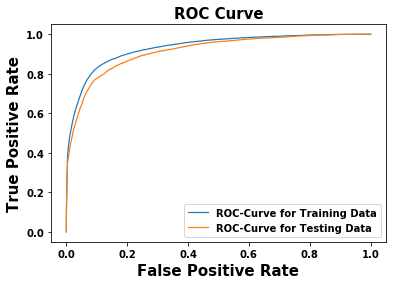

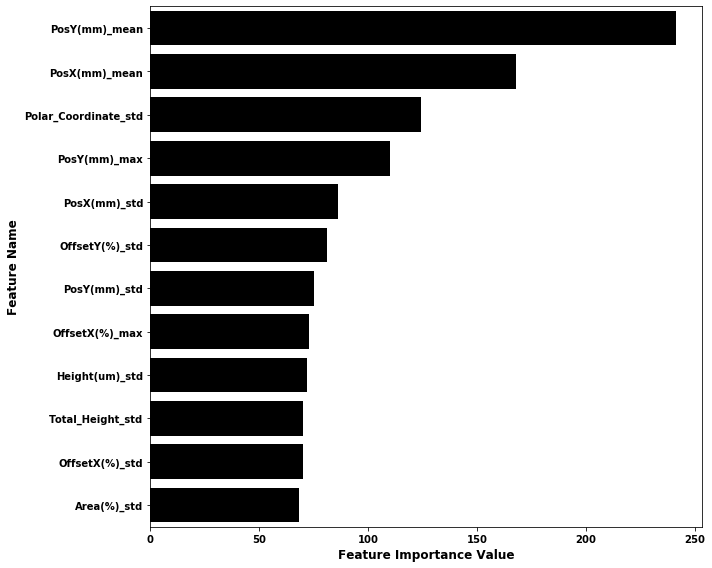

In [7]:
#%% 7] Plots

y_pred_proba_test = clf.predict_proba(X_test)[::,1]
fpr_te, tpr_te, _ = roc_curve(y_test,  y_pred_proba_test)

y_pred_proba_train = clf.predict_proba(X_train)[::,1]
fpr_tr, tpr_tr, _ = roc_curve(y_train,  y_pred_proba_train)

# A] ROC Curves for training and testing

plt.figure()
plt.plot(fpr_tr,tpr_tr,label="ROC-Curve for Training Data",linewidth = 1.2)
plt.plot(fpr_te,tpr_te,label="ROC-Curve for Testing Data",linewidth = 1.2)
plt.ylabel('True Positive Rate',fontsize=15,fontweight='bold')
plt.xlabel('False Positive Rate',fontsize=15,fontweight='bold')
plt.legend(loc="lower right")
plt.title('ROC Curve',fontsize=15,fontweight='bold')
plt.show()


# B] Top ten Best Features according to feature importance metric

feature_imp = pd.DataFrame(sorted(zip(clf.feature_importances_,X_train.columns)), columns=['Value','Feature'])

fig,ax = plt.subplots(figsize=(10, 8))
sns.barplot(x="Value", y="Feature", data=feature_imp.sort_values(by="Value", ascending=False).iloc[0:12,:],color = 'black')
plt.xticks(weight = 'bold', fontsize = 10)
plt.yticks(weight = 'bold', fontsize = 10)
plt.rcParams["font.weight"] = "bold"
ax.set_xlabel('Feature Importance Value', fontweight = 'bold', fontsize = 12)
ax.set_ylabel('Feature Name', fontweight = 'bold', fontsize = 12)
plt.tight_layout()
plt.show()
